In [2]:

import sys
import numpy as np
import pandas as pd
import copy
import argparse
import matplotlib.pyplot as plt

import os, shutil
from extractDataSrc.Lasco import Lasco
from datetime import datetime, timedelta

import sunpy.timeseries as ts
from sunpy.net import Fido, attrs as a
from extractDataSrc.Hapi import get_hapi_data

import sunpy
from sunpy.net import attrs as a
from astropy.time import Time
import astropy.units as u
import sunpy.map
import scipy.ndimage as ndi
import albumentations
import cv2 as cv
import scipy

from skimage import exposure
from skimage.feature import canny

from skimage.transform import hough_line, hough_line_peaks
from skimage.filters import meijering
from skimage.morphology import skeletonize
from skimage.morphology import disk, binary_opening, closing

from skimage.measure import label, regionprops
import math
from matplotlib.patches import Ellipse

from skimage import exposure
from skimage.feature import canny

from skimage.transform import hough_line, hough_line_peaks
from skimage.filters import meijering, frangi
from skimage.morphology import skeletonize
from skimage.morphology import disk, binary_opening

from PIL import Image
import json
import requests

In [ ]:


src_path = os.path.abspath(os.path.join(os.getcwd(), "./src"))

sys.path.append(src_path)

from src.dtw_measure import dtw_measure

from src.utils import set_seed, get_torch_device, load_config, \
    count_parameters, apply_glorot_xavier, inspect_gradient_norms

from src.preprocessing import get_k_fold, load_data, get_torch_data
from src.preprocessing import StandardScaler

from src.postprocessing import save_gradient_norms_plot, save_predictions_and_true_values_plot, \
    save_predictions_detail_plot, save_scatter_predictions_and_true_values, \
    get_dst_rmse, get_detail_properties, get_dtw_measures

# GRU development
This notebook will focus on predicting dst with GRU model trained on ideal events

**Further steps**:
1. Reproducing majirsky GRU with pytorch.
    - reproducing GRU-IE
    - reproducing GRU-ATTN_IEC
    - training, saving models and testing
4. If results same or similiar
    - proceed to assesing parameter analysis and importance
    - **Theory**: coronal holes concetration on sun disk is irrelevant to DST occurance and can be eliminated with minimal performance loss
5. Process data in MESWE format for ideal events.
6. Train on ideal events
  Compare results


## 1. Reproducing and training GRU_IE

This is done in a google colab, due to cloud based traning of the neural network

## 2. reproducing and training GRU-ATTN-IEC

This will also be done in google colab. From both models .pth file will be saved and used further in this notebook for analysis and predictions

## 3. Attribute importance assesment for GRU_IE

### Load data

In [5]:
config_file_name = "conf_gru_ie_1_1_1.yaml"
seed_input = 42
device_input = "cpu"

# we extract all hyperparameters settings from .yamls, it was handy when we were finetuning hyperparameters
EXPERIMENT_NAME = "gru_ie_1_1_1"
# uncomment this line to save also seed you running
#EXPERIMENT_NAME = EXPERIMENT_NAME + "__" + seed_input
EXPERIMENT_NOTES = "None"

set_seed(seed_input)
device = get_torch_device(device_input)

BATCH_SIZE = 32
LEARNING_RATE = 1.0e-05
NUM_EPOCHS = 200
WEIGHT_DECAY = 0.1
AUGUMENTATION_RATE = 0.1

INPUT_SIZE = 9
HIDDEN_CHANNELS = 64
OUTPUT_SIZE = 1
NUM_GRU_LAYERS = 2
DROPOUT = 0.2

TIME_STEPS = 100
PREDICTION_WINDOW = 10
K_FOLD = 1

seed 42 set
cpu


In [6]:
file_ids_train, file_ids_val, file_ids_test = get_k_fold(K_FOLD)

train_X_unscaled, train_y_unscaled = load_data(file_ids_train, time_steps=TIME_STEPS, sliding_window=PREDICTION_WINDOW, folder_path="./data/MESWE/")
val_X_unscaled, val_y_unscaled = load_data(file_ids_val, time_steps=TIME_STEPS, sliding_window=PREDICTION_WINDOW, folder_path="./data/MESWE/")
test_X_unscaled, test_y_unscaled = load_data(file_ids_test, time_steps=TIME_STEPS, sliding_window=PREDICTION_WINDOW, folder_path="./data/MESWE/")

#droping Q1-4 data (datetime colmn was dropped in load_data())
train_X_unscaled = train_X_unscaled[:, :, 4:]
val_X_unscaled = val_X_unscaled[:, :, 4:]
test_X_unscaled = test_X_unscaled[:, :, 4:]


standard_scaler = StandardScaler(train_X_unscaled, train_y_unscaled)

train_X = standard_scaler.standardize_X(train_X_unscaled)
val_X = standard_scaler.standardize_X(val_X_unscaled)
test_X =standard_scaler.standardize_X(test_X_unscaled)

train_y = standard_scaler.standardize_y(train_y_unscaled)
val_y = standard_scaler.standardize_y(val_y_unscaled)
test_y = standard_scaler.standardize_y(test_y_unscaled)

train_X, train_y = get_torch_data(train_X, train_y)
val_X, val_y = get_torch_data(val_X, val_y)
test_X, test_y = get_torch_data(test_X, test_y)


train_dataset = torch.utils.data.TensorDataset(train_X, train_y)
val_dataset = torch.utils.data.TensorDataset(val_X, val_y)
test_dataset = torch.utils.data.TensorDataset(test_X, test_y)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [10]:
class GRUModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_gru_layers, dropout):
        super(GRUModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_gru_layers = num_gru_layers

        self.gru = nn.GRU(input_size, hidden_size, num_gru_layers, batch_first=True, bidirectional=False, dropout=dropout)

        self.fc1 = nn.Linear(hidden_size, output_size)

        self.relu = nn.ReLU()

    def forward(self, x):

        h0 = torch.zeros(self.num_gru_layers, x.size(0), self.hidden_size).to(x.device)
        out, _ = self.gru(x, h0)

        out = self.fc1(out[:, -1, :])

        return out

model = GRUModel(input_size=INPUT_SIZE, hidden_size=HIDDEN_CHANNELS, output_size=OUTPUT_SIZE, num_gru_layers=NUM_GRU_LAYERS, dropout=DROPOUT)
model.load_state_dict(torch.load("./models/GRU_IE.pth"))
model.eval()

GRUModel(
  (gru): GRU(9, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc1): Linear(in_features=64, out_features=1, bias=True)
  (relu): ReLU()
)

### Permutation importance

This works by permuting data for parameter i, this breaks the relationship between the data and the prediction. If there is a increse in error, than the permuted parameter is inmportant for the prediction. This is done for every parameter and stored, than plotted for comparison.

However this approach is prone to fail when a parameter has rather low variance, as permuting its values wont change much, it would also not really increase the error. Thus more robust method is needed for **Coronal Holes** parameters.

In [11]:
from sklearn.metrics import mean_squared_error

n_samples, _, n_features = test_X.shape
y_pred_baseline = model(test_X).squeeze().detach().numpy()
baseline_score = mean_squared_error(test_y.squeeze(), y_pred_baseline)

feature_names = ['N_CH', 'R_CH', 'S_CH', 'L_CH', 'C_CH', 'V_p', 'N_p', 'B_z', 'DST']

importance_scores = {}

for i, feature_name in enumerate(feature_names):
  X_permuted = test_X.detach().numpy().copy()
  shuffled_indices = np.random.permutation(n_samples) 
  X_permuted[:, :, i] = X_permuted[shuffled_indices, :, i]

  y_pred_permuted = model(torch.from_numpy(X_permuted)).squeeze().detach().numpy()
  permuted_score = mean_squared_error(test_y.squeeze(), y_pred_permuted)
  importance = permuted_score - baseline_score

  importance_scores[feature_name] = importance

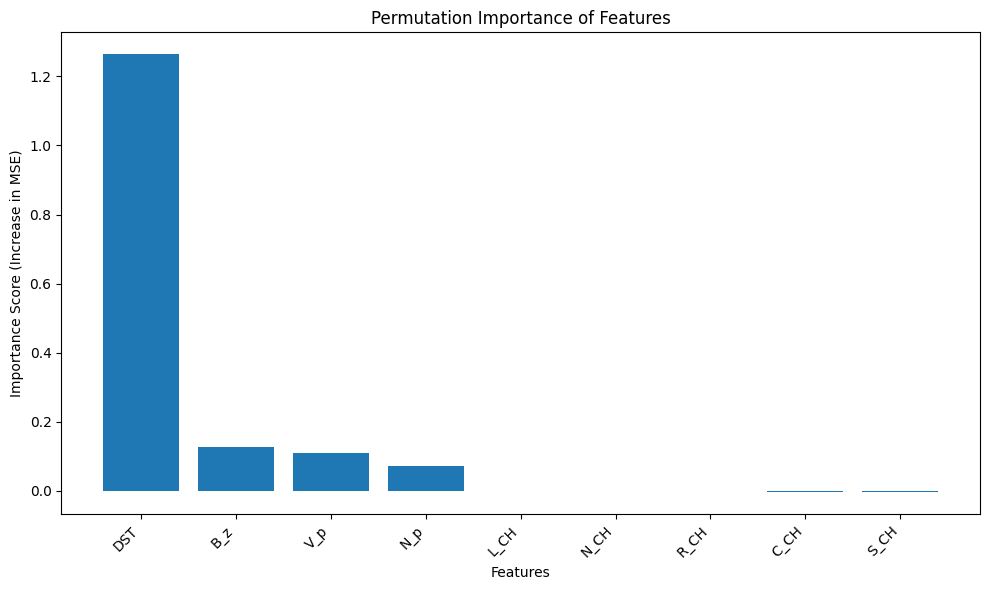

In [12]:
# Sort the importance scores for better visualization
sorted_importance_scores = dict(sorted(importance_scores.items(), key=lambda item: item[1], reverse=True))

# Extract feature names and scores
features = list(sorted_importance_scores.keys())
scores = list(sorted_importance_scores.values())

# Create the bar plot
plt.figure(figsize=(10, 6))
plt.bar(features, scores)
plt.xlabel("Features")
plt.ylabel("Importance Score (Increase in MSE)")
plt.title("Permutation Importance of Features")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Sensitivity Analysis

This works by calculating partial derivative of the prediction with respect to the input parameters and taking the absolute value:
$$\left|\frac{\partial \text{output}}{\partial \text{input param}}\right|$$
By taking the absolute value we looking just on the magnitude of the change. These changes then tells how important is the parameter to the model, the greater the derivative, the greater the change in the parameter causes greater change in the output of the model.
$$
\nabla_{input} = \left( \left|\frac{\partial \text{output}}{\partial C_{CH}}\right|, \left|\frac{\partial \text{output}}{\partial L_{CH}}\right|, \dots, \left|\frac{\partial \text{output}}{\partial DST}\right|  \right)
$$

In [16]:
test_X.requires_grad_(True)
print('ok')

ok


In [20]:
y_pred = model(test_X)

scalar_output = y_pred.sum()
scalar_output.backward()
gradT = test_X.grad

In [40]:
importance_scores_grads = {}
for i, feature_name in enumerate(feature_names):
    importance_scores_grads[feature_name] = torch.abs(gradT[:,:,i]).mean().item()

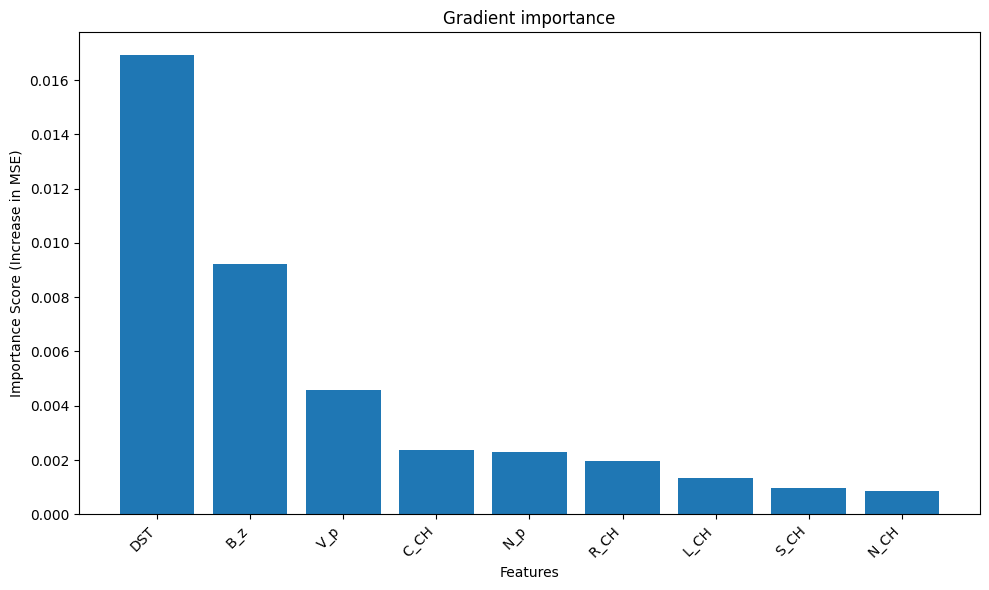

In [41]:
# Sort the importance scores for better visualization
sorted_importance_scores = dict(sorted(importance_scores_grads.items(), key=lambda item: item[1], reverse=True))

# Extract feature names and scores
features = list(sorted_importance_scores.keys())
scores = list(sorted_importance_scores.values())

# Create the bar plot
plt.figure(figsize=(10, 6))
plt.bar(features, scores)
plt.xlabel("Features")
plt.ylabel("Importance Score (Increase in MSE)")
plt.title("Gradient importance")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Zeroing out

In [42]:
feature_names = ['N_CH', 'R_CH', 'S_CH', 'L_CH', 'C_CH', 'V_p', 'N_p', 'B_z', 'DST']

importance_scores_zeroing = {}

for i, feature_name in enumerate(feature_names):
  X_zeroed = test_X.detach().numpy().copy()
  X_zeroed[:, :, i] = 0.0

  y_pred_zeroed = model(torch.from_numpy(X_zeroed)).squeeze().detach().numpy()
  zeroed_score = mean_squared_error(test_y.squeeze(), y_pred_zeroed)
  importance = zeroed_score - baseline_score

  importance_scores_zeroing[feature_name] = importance

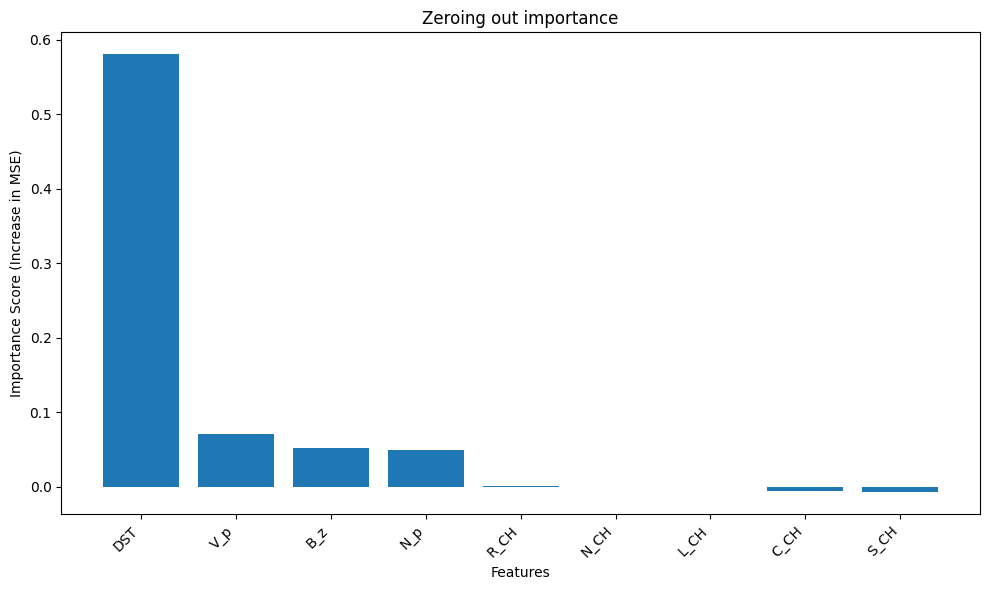

In [43]:
# Sort the importance scores for better visualization
sorted_importance_scores = dict(sorted(importance_scores_zeroing.items(), key=lambda item: item[1], reverse=True))

# Extract feature names and scores
features = list(sorted_importance_scores.keys())
scores = list(sorted_importance_scores.values())

# Create the bar plot
plt.figure(figsize=(10, 6))
plt.bar(features, scores)
plt.xlabel("Features")
plt.ylabel("Importance Score (Increase in MSE)")
plt.title("Zeroing out importance")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 4. Attribution performance for GRU-ATTN-IEC

### Load data

In [2]:
def train_model(model, train_loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for inputs, targets in train_loader:
        # ----split coronagraph data (first four columns) and other data
        quadrands_inputs = inputs[:, :, :4].to(device)
        inputs = inputs[:, :, 4:].to(device)
        #---------------
        targets = targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs, quadrands_inputs)
        targets = targets.squeeze(-1)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    mean_loss = total_loss / len(train_loader)
    return mean_loss


def validate_model(model, val_test_loader, criterion, device):
    model.eval()
    total_loss = 0
    all_outputs = []
    
    with torch.no_grad():
        for inputs, targets in val_test_loader:
            quadrands_inputs = inputs[:, :, :4].to(device)
            inputs = inputs[:, :, 4:].to(device)
            targets = targets.to(device)
            outputs = model(inputs, quadrands_inputs)
            all_outputs.append(outputs.squeeze(-1))
            targets = targets.squeeze(-1)
            loss = criterion(outputs, targets)
            total_loss += loss.item()
    
    mean_loss = total_loss / len(val_test_loader)
    all_outputs = torch.cat(all_outputs, dim=0)
    return mean_loss, all_outputs


class QKVAttention(nn.Module):
    """Multi-Head Scaled Dot-Product Attention"""
    def __init__(self, hidden_size, num_heads):
        super(QKVAttention, self).__init__()
        self.num_heads = num_heads
        self.hidden_size = hidden_size
        
        self.mha = nn.MultiheadAttention(embed_dim=hidden_size, num_heads=num_heads, batch_first=True)

    def forward(self, query, key, value):
        """
        query: [batch_size, 1, hidden_size]  (previous hidden state)
        key: [batch_size, seq_len, hidden_size] (GRU outputs)
        value: [batch_size, seq_len, hidden_size] (GRU outputs)
        """
        attn_output, attn_weights = self.mha(query, key, value)
        attn_output = attn_output.squeeze(1)  # [batch_size, hidden_size]
        
        return attn_output, attn_weights
    

class GRUWithQKVAttention(nn.Module):
    """GRU layer followed by QKV Self-Attention"""
    def __init__(self, input_size, hidden_size, num_layers, num_heads):
        super(GRUWithQKVAttention, self).__init__()
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True, dropout=0.0)
        self.attention = QKVAttention(hidden_size, num_heads)

    def forward(self, x, h):
        output, _ = self.gru(x, h)  # [batch_size, seq_len, hidden_size]
        context, attention_weights = self.attention(output[:, -1:, :], output, output)
        return context, attention_weights
    

class GRUModelWithAttention(nn.Module):
    """Complete Model with GRU + Multi-Head QKV Attention"""
    def __init__(self, input_size, hidden_size, hidden_size2, output_size, num_gru_layers, dropout, num_heads):
        super(GRUModelWithAttention, self).__init__()
        
        self.num_gru_layers = num_gru_layers
        
        self.hidden_size = hidden_size
        self.gru1 = nn.GRU(input_size, hidden_size, num_gru_layers, batch_first=True, bidirectional=False, dropout=0.0)
        
        # found that mapping coronagraph visual features (Q-data) to 16-dim works best
        self.linear1 = nn.Linear(4, 16)
        
        self.hidden_size2 = hidden_size2
        self.gru2 = GRUWithQKVAttention(16, self.hidden_size2, num_gru_layers, num_heads)
        
        self.fc_out = nn.Linear(hidden_size + hidden_size2, output_size)
        self.gelu = nn.GELU()

    def forward(self, x, x_q):
        h0 = torch.zeros(self.num_gru_layers, x.size(0), self.hidden_size).to(x.device)
        out1, _ = self.gru1(x, h0)

        x_q = self.gelu(self.linear1(x_q))

        h02 = torch.zeros(self.num_gru_layers, x_q.size(0), self.hidden_size2).to(x.device)
        context, weights = self.gru2(x_q, h02)

        concated = torch.cat((out1[:, -1, :], context), 1)
        out = self.fc_out(concated)
        return out

def bin_features(X, feature_indices, bins):
    X_binned = X.copy()
    for idx in feature_indices:
        X_binned[..., idx] = np.digitize(X[..., idx], bins=bins, right=False)
    return X_binned


def separate_features(data, binned_indices, scaled_indices):
    binned_features = data[..., binned_indices]
    scaled_features = data[..., scaled_indices]
    return binned_features, scaled_features


def combine_features(binned, scaled):
    return np.concatenate([binned, scaled], axis=-1)

In [3]:
TIME_STEPS = 200
K_FOLD = 1
PREDICTION_WINDOW = 10
BATCH_SIZE = 32

INPUT_SIZE = 9
HIDDEN_CHANNELS1 = 256
HIDDEN_CHANNELS2 = 256
OUTPUT_SIZE = 1
NUM_GRU_LAYERS = 2
DROPOUT =  0.0

device='cpu'

In [4]:
###########################
#PART 2: PREPARING DATA
###########################

file_ids_train, file_ids_val, file_ids_test = get_k_fold(K_FOLD)

train_X_unscaled, train_y_unscaled = load_data(file_ids_train, time_steps=TIME_STEPS, sliding_window=PREDICTION_WINDOW)
val_X_unscaled, val_y_unscaled = load_data(file_ids_val, time_steps=TIME_STEPS, sliding_window=PREDICTION_WINDOW)
test_X_unscaled, test_y_unscaled = load_data(file_ids_test, time_steps=TIME_STEPS, sliding_window=PREDICTION_WINDOW)

#standard_scaler = StandardScaler(train_X_unscaled, train_y_unscaled)

#--------conver coronagraph visual features (Q-DATA) from number to category -- categorization------------
# - similar as savgol filter in preprocessing.load_data() categorization can be left out, but we figured out that it gives small performance boost, so we kept it here

standard_scaler = StandardScaler(train_X_unscaled[..., 4:], train_y_unscaled)

bin_edges = [0, 3.0, 5.0, 15.0, 30.0, 100.0]  
features_to_bin = [0, 1, 2, 3]
features_to_scale = range(4, train_X_unscaled.shape[-1])

# separate binned q-data and scaled features
train_binned, train_to_scale = separate_features(train_X_unscaled, range(4), features_to_scale)
val_binned, val_to_scale = separate_features(val_X_unscaled, range(4), features_to_scale)
test_binned, test_to_scale = separate_features(test_X_unscaled, range(4), features_to_scale)

# standardize only the scaled features
train_scaled = standard_scaler.standardize_X(train_to_scale)
val_scaled = standard_scaler.standardize_X(val_to_scale)
test_scaled = standard_scaler.standardize_X(test_to_scale)

train_X_binned = bin_features(train_binned, features_to_bin, bin_edges) 
val_X_binned = bin_features(val_binned, features_to_bin, bin_edges) 
test_X_binned = bin_features(test_binned, features_to_bin, bin_edges) 

# combine bined q-data and standardized numeric insitu
train_X = combine_features(train_X_binned, train_scaled)
val_X = combine_features(val_X_binned, val_scaled)
test_X = combine_features(test_X_binned, test_scaled)

#-----------------------------------------

#train_X = standard_scaler.standardize_X(train_X_unscaled)
#val_X = standard_scaler.standardize_X(val_X_unscaled)
#test_X =standard_scaler.standardize_X(test_X_unscaled)

# standardize y
train_y = standard_scaler.standardize_y(train_y_unscaled)
val_y = standard_scaler.standardize_y(val_y_unscaled)
test_y = standard_scaler.standardize_y(test_y_unscaled)

train_X, train_y = get_torch_data(train_X, train_y)
val_X, val_y = get_torch_data(val_X, val_y)
test_X, test_y = get_torch_data(test_X, test_y)

train_dataset = torch.utils.data.TensorDataset(train_X, train_y)
val_dataset = torch.utils.data.TensorDataset(val_X, val_y)
test_dataset = torch.utils.data.TensorDataset(test_X, test_y)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [5]:
model = GRUModelWithAttention(
    input_size=INPUT_SIZE, 
    hidden_size=HIDDEN_CHANNELS1, 
    hidden_size2=HIDDEN_CHANNELS2, 
    output_size=OUTPUT_SIZE, 
    num_gru_layers=NUM_GRU_LAYERS, 
    dropout=DROPOUT, num_heads=2
)

model.load_state_dict(torch.load("./models/GRU_ATTN.pth", map_location=torch.device('cpu')))
model.eval()

GRUModelWithAttention(
  (gru1): GRU(9, 256, num_layers=2, batch_first=True)
  (linear1): Linear(in_features=4, out_features=16, bias=True)
  (gru2): GRUWithQKVAttention(
    (gru): GRU(16, 256, num_layers=2, batch_first=True)
    (attention): QKVAttention(
      (mha): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
      )
    )
  )
  (fc_out): Linear(in_features=512, out_features=1, bias=True)
  (gelu): GELU(approximate='none')
)

### Making predictions

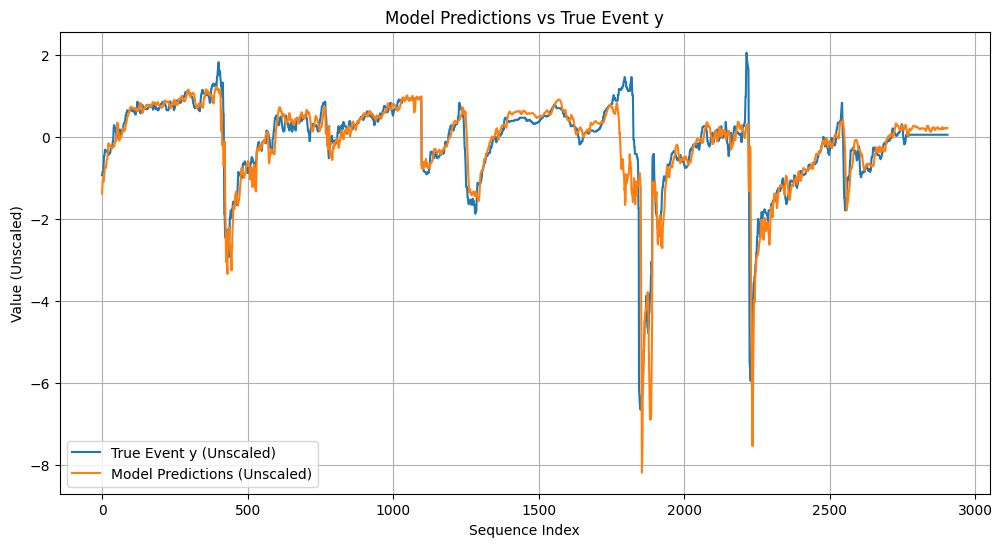

In [6]:
with torch.no_grad():
  quadrands_inputs = test_X[:, :, :4].to(device)
  inputs = test_X[:, :, 4:].to(device)
  y_pred = model(inputs, quadrands_inputs)


plt.figure(figsize=(12, 6))
plt.plot(test_y.squeeze().cpu().numpy(), label='True Event y (Unscaled)')
plt.plot(y_pred.squeeze().cpu().numpy(), label='Model Predictions (Unscaled)')


plt.xlabel("Sequence Index")
plt.ylabel("Value (Unscaled)")
plt.title(f"Model Predictions vs True Event y")
plt.legend()
plt.grid(True)
plt.show()

### Permutation importance GRU-ATTN-IEC

In [ ]:
from sklearn.metrics import mean_squared_error

n_samples, _, n_features = test_X.shape
y_pred_baseline = model(test_X[:, :, 4:], test_X[:, :, :4]).squeeze().detach().numpy()
baseline_score = mean_squared_error(test_y.squeeze(), y_pred_baseline)

feature_names = ['Q1', 'Q2', 'Q3', 'Q4', 'N_CH', 'R_CH', 'S_CH', 'L_CH', 'C_CH', 'V_p', 'N_p', 'B_z', 'DST']

importance_scores = {}

for i, feature_name in enumerate(feature_names):
    X_permuted = test_X.detach().numpy().copy()
    shuffled_indices = np.random.permutation(n_samples) 
    X_permuted[:, :, i] = X_permuted[shuffled_indices, :, i]

    X_permuted_tensor = torch.from_numpy(X_permuted)
    
    y_pred_permuted = model(X_permuted_tensor[:, :, 4:], X_permuted_tensor[:, :, :4]).squeeze().detach().numpy()
    permuted_score = mean_squared_error(test_y.squeeze(), y_pred_permuted)
    importance = permuted_score - baseline_score
    
    importance_scores[feature_name] = importance

# 3 Process ideal events to MESWE format

Here the main steps are:
1. coronograph images segment to 4 quadrants, make running difference and make time series of change in pixels
    - Would like to make better detection of chages, as lots of halos are really faint.
3. download in situ data
4. coronal holes activity time sereis ? (maybe, will decide if it is feasible or needed even)

## 1 Coronograph HALO detection

In [4]:
def download_metadata(time_str):
    original_datetime = datetime.strptime(time_str, "%Y-%m-%d %H:%M:%S")
    date_str = original_datetime.strftime("%Y-%m-%dT%H:%M:%S.000Z")
    url = f"https://api.helioviewer.org/v2/getClosestImage/?date={date_str}&sourceId=5"

    try:
        response = requests.get(url)
        response.raise_for_status()  # Raise an error for bad status codes
        
        data = response.json()
        
        # Save the JSON data to the specified path
        with open("./data_processed/lasco/c3/images_metadata" + ".json", 'w') as f:
            json.dump(data, f, indent=4)
    

    except requests.exceptions.RequestException as e:
        print(f"Error fetching data from Helioviewer API: {e}")
    except IOError as e:
        print(f"Error saving file to ./data_processed/lasco/c3/images_metadata.json: {e}")

In [ ]:
print('Downloading coronograph images -----------------')
    
folder = './data_processed/lasco/c3/'
for filename in os.listdir(folder):
    file_path = os.path.join(folder, filename)
    try:
        if os.path.isfile(file_path) or os.path.islink(file_path):
            os.unlink(file_path)
        elif os.path.isdir(file_path):
            shutil.rmtree(file_path)
    except Exception as e:
        print('Failed to delete %s. Reason: %s' % (file_path, e))

start_date = '2024-08-08 15:00:00'
stop_date = '2024-08-09 02:00:00'

download_metadata(start_date)
lasco = Lasco(start_date, stop_date)
lasco.extract_data("c3")


Creating Screenshots: 100%|██████████| 20/20 [01:03<00:00,  3.20s/image]


In [3]:
images = []

# for im in os.listdir('./data_processed/lasco/c3'):
#     if (im.endswith(".png")):
#         img = Image.open('./data_processed/lasco/c3/' + im)
#         images.append(np.array(img.convert('L')))

main_image_dir = './data_processed/testing_images_c3/event0/'

for im in os.listdir(main_image_dir):
    if (im.endswith(".png")):
        img = Image.open(main_image_dir + im)
        images.append(np.array(img.convert('L')))

len(images), images[0].shape 

(67, (1024, 1024))

In [4]:
files = [f for f in os.listdir(main_image_dir) if f.endswith('.png')]
files.sort() 

time_strings = []
for im in files:
    parts = im.split('_')
    
    date_part = parts[0]
    time_part = parts[1]
    
    full_time_str = f"{date_part}_{time_part}"
    time_strings.append(full_time_str)

times = pd.to_datetime(time_strings, format='%Y%m%d_%H%M')

t0 = times[0]
cum_times = np.array([(t - t0).total_seconds() for t in times])

cum_times

array([    0.,   720.,  1440.,  2160.,  2880.,  5040.,  5760.,  6480.,
        7200.,  7920.,  8640.,  9360., 10800., 11520., 12240., 12960.,
       13680., 14400., 15120., 15840., 16560., 17280., 18000., 18720.,
       19440., 20160., 20880., 21600., 22320., 23040., 23760., 24480.,
       25200., 25920., 26640., 27360., 28080., 28800., 29520., 30240.,
       30960., 32400., 33120., 33840., 34560., 35280., 36000., 36720.,
       37440., 38160., 38880., 39600., 40320., 41040., 41760., 42480.,
       43200., 43920., 44640., 45360., 46080., 48240., 48960., 49680.,
       50400., 51120., 51840.])

In [5]:
# Replace with your file paths
png_file = f'data_processed/lasco/c3/{os.listdir(main_image_dir)[0]}'

# Open the image file
img = Image.open(png_file)

# Convert the image to a NumPy array for analysis
# 'L' (Luminance) mode is often best for single-channel solar images
image_data = np.array(img.convert('L'))

# Check the data type and shape
image_data.dtype, image_data.shape

(dtype('uint8'), (1024, 1024))

In [6]:
json_file = f'{main_image_dir}/images_metadata.json'

with open(json_file, 'r') as f:
    metadata = json.load(f)

metadata

{'id': '125651078',
 'date': '2015-06-20 23:54:07',
 'name': 'LASCO C3',
 'scale': 56,
 'scaleCorrection': 1,
 'width': 1024,
 'height': 1024,
 'refPixelX': 519.116,
 'refPixelY': 533.477,
 'offsetX': 0,
 'offsetY': 0,
 'rotation': 6.82483,
 'rsun': 17.1365,
 'dsun': 149597870700,
 'sunCenterOffsetParams': [],
 'layeringOrder': 3}

### Coordinate system transformation
We will recalculate every pixel so that it is relative to the center of the Sun. Which is defined by the $c_x$ and $c_y$, where $\mathbf{c}$ is the position of the sun in the image parameters referenced in the metadata. With this we will effectively change the coordinate system where $(0,0)$ will be the sun instead of the top left corner of the image. 

Than we calculate scale how much arcseconds 1 pixel is. This is also defined in the metadata. We will denote it as $\Theta_{arcsec}$.

$r_{sun}$ is the angular radius of the Sun in pixels. Angular radius is radius in degrees of the Sun as seen from LASCO sattelite.

$x_{rel}$ and $y_{rel}$ are relative coordinates of the pixel to the center of the Sun. 

In [7]:
center_x = 512
center_y = 512

arcsec_per_pixel = metadata['scale']
ARCSEC_TO_KM = 725.0    # Approximate conversion at 1 AU
V_MIN_KM_S = 250.0      # Minimum plausible CME speed
V_MAX_KM_S = 2000.0     # Maximum plausible CME speed
rsun_pixels = metadata['rsun']

height, width = image_data.shape

y_indices, x_indices = np.indices((height, width))

x_rel_pixels = x_indices - center_x
y_rel_pixels = center_y - y_indices

x_arcsec = x_rel_pixels * arcsec_per_pixel
y_arcsec = y_rel_pixels * arcsec_per_pixel

r_arcsec = np.sqrt(x_arcsec**2 + y_arcsec**2)

theta_arcsec = np.arctan2(y_arcsec, x_arcsec)
theta_arcsec = np.mod(theta_arcsec, 2 * np.pi)

### Masking out occulter, occulter pylon and black edges

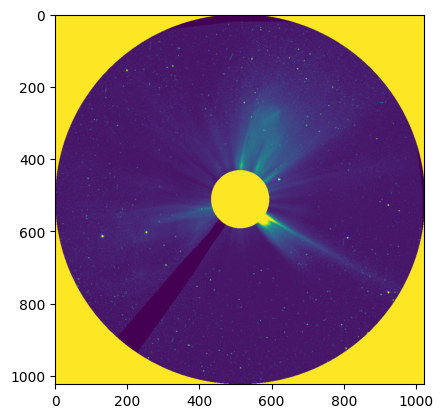

In [8]:
image_data_temp = image_data.copy()
image_data_temp[r_arcsec < 4.7*rsun_pixels*arcsec_per_pixel] = 255
image_data_temp[r_arcsec > 512*arcsec_per_pixel] = 255
plt.imshow(image_data_temp)


Calculating polar version of image to mask out the occulter pylon. For that we will use the fomrulas
$$
r' = \sqrt{x'^2 + y'^2}
$$
$$
\theta' = \arctan\left(\frac{y'}{x'}\right)
$$

We will need to find the pylonn mask algorithmically. Let 
$$
P = \left(\theta' > X\pi \right) \land \left(\theta' < \left( X - \frac{7}{100}\right)\pi\right)
$$

Where X is a fraction. Angle in radians is $\frac{a}{b}\pi$. We have to find the fraction $X = \frac{a}{b}$ so that it matches the pylon in the image. The pylon of the occulter can move and is not the same for every event. Thus the $X$ is decided by following algorithm:
1. Define a donut slice $P$ as a window which would be later the pylon mask with angle $\phi$ starting at 0 radians.
2. Increment the angle by some small $\delta$, so $\phi = \phi + \delta$, this way we slide the donut window
3. caculate % number of black pixels in this donut slice, we denote it as $D = \frac{|P < 5|}{|P|}$.
4. Record the maximum $D$ and store the angle for that $D$. 
5. Than $\phi = X$ and mask for pylon is than: 
$$
\left(\theta' > \phi\pi \right) \land \left(\theta' < \left( \phi - \frac{7}{100}\right)\pi\right)
$$

In [9]:
image_polar_testing = image_data_temp.copy()

best_pylon_cover = None
best_pylon_angle = None
for pylon_angle in np.arange(0.01, 2, 0.01):
    pylon_mask = (theta_arcsec < pylon_angle*np.pi) & \
                (theta_arcsec > (pylon_angle - 7/100)*np.pi) & \
                (r_arcsec > 4.7*rsun_pixels*arcsec_per_pixel) & \
                (r_arcsec < 512*arcsec_per_pixel)


    pylon = image_polar_testing[pylon_mask]
    match_count = np.sum(pylon < 5)
    total_count = len(pylon)


    if best_pylon_cover is None or match_count / total_count > best_pylon_cover:
        best_pylon_cover = match_count / total_count
        best_pylon_angle = pylon_angle

best_pylon_angle, best_pylon_cover

(np.float64(1.33), np.float64(0.7361249466344101))

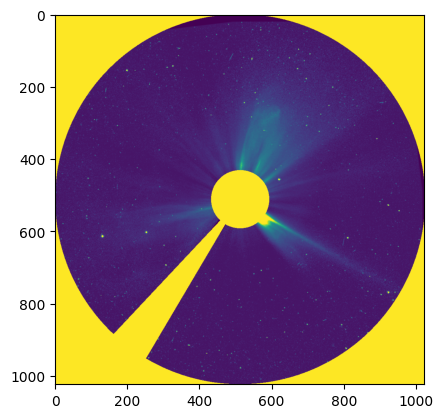

In [10]:
pylon_mask = (theta_arcsec < best_pylon_angle*np.pi) & \
                (theta_arcsec > (best_pylon_angle - 7/100)*np.pi) & \
                (r_arcsec > 4.7*rsun_pixels*arcsec_per_pixel) & \
                (r_arcsec < 512*arcsec_per_pixel)

image_polar_testing[pylon_mask] = 255
plt.imshow(image_polar_testing)

Final mask:
$$
r' < 4.7r_{sun} \lor r' > 512 \lor \left[ \left(\theta' > \phi \right) \land \left(\theta' < \left( \phi - \frac{7}{100}\right)\pi\right)\right]
$$

In [11]:
mask = (r_arcsec < 4.7*rsun_pixels*arcsec_per_pixel
       ) | (r_arcsec > 512*arcsec_per_pixel
       ) | ((theta_arcsec < best_pylon_angle*np.pi) & (theta_arcsec > (best_pylon_angle - 7/100)*np.pi))

image_data_masked = image_data.copy().astype(np.float32)
image_data_masked[mask] = np.nan

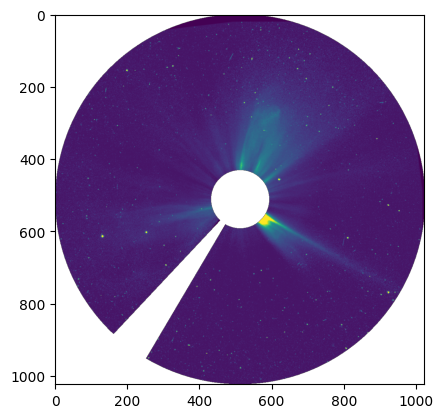

In [12]:
plt.imshow(image_data_masked)

In [13]:
def prepare_image(image, phi):
    height, width = image_data.shape

    y_indices, x_indices = np.indices((height, width))

    x_rel_pixels = x_indices - center_x
    y_rel_pixels = y_indices - center_y

    x_arcsec = x_rel_pixels * arcsec_per_pixel
    y_arcsec = y_rel_pixels * arcsec_per_pixel

    r_arcsec = np.sqrt(x_arcsec**2 + y_arcsec**2)

    """
    Mask out sun, occulter, edges
    """
    theta_arcsec = np.arctan2(y_arcsec, x_arcsec)
    mask = (r_arcsec < 4.7*rsun_pixels*arcsec_per_pixel
       ) | (r_arcsec > 512*arcsec_per_pixel
       ) | ((theta_arcsec < phi*np.pi) & (theta_arcsec > (phi - 7/100)*np.pi))

    image_data_masked = image.copy().astype(np.float32)
    image_data_masked[mask] = np.nan

    return image_data_masked, r_arcsec, theta_arcsec

In [14]:
prepared_images = []
prepared_r_arcsecs = []
prepared_theta_arcsecs = []

for image in images:
    im, r, t = prepare_image(image, best_pylon_angle)
    prepared_images.append(im)
    prepared_r_arcsecs.append(r)
    prepared_theta_arcsecs.append(t)



In [15]:
def show_images(ims):
    n_rows = int(np.ceil(np.sqrt(len(ims))))
    n_cols = int(np.ceil(len(ims) / n_rows))

    plt.figure(figsize=(10, 10))

    folder = './imgs/processed_c3_testing/'
    for filename in os.listdir(folder):
        file_path = os.path.join(folder, filename)
        try:
            if os.path.isfile(file_path) or os.path.islink(file_path):
                os.unlink(file_path)
            elif os.path.isdir(file_path):
                shutil.rmtree(file_path)
        except Exception as e:
            print('Failed to delete %s. Reason: %s' % (file_path, e))

    for i in range(len(ims)):
        ax = plt.subplot(n_rows, n_cols, i + 1)
        plt.imshow(ims[i])
        ax.set_xticks([])
        ax.set_yticks([])

        img = Image.fromarray((ims[i]).astype(np.uint8), mode='L')
        img.save('./imgs/processed_c3_testing/' + str(i) + '.png')


    plt.tight_layout()

### Unrolling image to polar map

In [16]:
def unroll_to_polar(image_data, r_arcsec_array, theta_arcsec_array, 
                    num_radii=512, num_angles=360):
    """
    Converts a single Cartesian image (image_data) to a Polar (R, Theta) map.

    Args:
        image_data (np.ndarray): The 2D image data (after masking).
        r_arcsec_array (np.ndarray): The calculated radial distances (in arcsec).
        theta_arcsec_array (np.ndarray): The calculated angles (in radians).
        num_radii (int): The desired number of radial bins.
        num_angles (int): The desired number of angular bins (0-360 degrees).

    Returns:
        np.ndarray: The 2D polar map (num_radii x num_angles).
    """
    height, width = image_data.shape
    
    R_max = r_arcsec_array.max()
    R_new = np.linspace(r_arcsec_array.min(), R_max, num_radii)
    Theta_new = np.linspace(0, 2 * np.pi, num_angles, endpoint=False)
    R_grid, Theta_grid = np.meshgrid(R_new, Theta_new)
    
    occulter_center_x = 512.0
    occulter_center_y = 512.0
    
    indices_x = occulter_center_x + R_grid * np.cos(Theta_grid) / arcsec_per_pixel
    indices_y = occulter_center_y + R_grid * np.sin(Theta_grid) / arcsec_per_pixel

    coords = np.vstack([indices_y.ravel(), indices_x.ravel()])

    polar_map = scipy.ndimage.map_coordinates(
        input=image_data, 
        coordinates=coords, 
        order=1,  # Linear interpolation
        cval=np.nan # Use NaN for masked/out-of-bounds areas
    ).reshape(num_angles, num_radii)
    
    return polar_map.T

In [17]:
polar_maps = []

for image, r_arcsec, theta_arcsec in zip(prepared_images, prepared_r_arcsecs, prepared_theta_arcsecs) :
    polar_maps.append(unroll_to_polar(image, r_arcsec, theta_arcsec))

In [18]:
running_difference = []

for i in range(1, len(polar_maps)):
    running_difference.append(
        np.clip(polar_maps[i] - polar_maps[i-1], 0, 255)
    )


### J-maps

In [19]:
def create_jmap(diff_ims, center_angle, angular_width=5):
    j_map_slices = []
    
    # Calculate the bounds of the swath
    half_width = angular_width // 2
    
    # Make sure we don't accidentally slice outside the array bounds
    max_angle = diff_ims[0].shape[1]
    start_angle = max(0, center_angle - half_width)
    end_angle = min(max_angle, center_angle + half_width + 1)
    
    for polar_map in diff_ims[::-1]:
        # Extract a 2D chunk: [All Radii, Swath of Angles]
        swath = polar_map[:, start_angle:end_angle]
        
        # Average across the angular axis (axis=1) to create a single clean 1D line
        # Use np.nanmean just in case there are missing data pixels (NaNs) in the image
        clean_radial_slice = np.nanmean(swath, axis=1)
        
        j_map_slices.append(clean_radial_slice)
        
    j_map = np.stack(j_map_slices, axis=0)
    
    return j_map

### detecet CMEs with Hough Transform 

In [123]:
def cme_hough_transform(j_map, percentil, disk_size, verbose=True):
    j_map_clean = np.nan_to_num(j_map, nan=0.0, posinf=0.0, neginf=0.0)
    p1, p99 = np.percentile(j_map_clean, (1, 99))
    j_map_clipped = np.clip(j_map_clean, p1, p99)
    j_map_norm = (j_map_clipped - j_map_clipped.min()) / (j_map_clipped.max() - j_map_clipped.min())
    j_map_eq = exposure.equalize_adapthist(j_map_norm, clip_limit=0.03)

    j_map_blobs = meijering(j_map_eq, sigmas=range(1, 4), black_ridges=False)
    threshold = np.percentile(j_map_blobs, percentil) 
    binary_j_map = j_map_blobs > threshold

    skeleton_map = skeletonize(binary_j_map)

    tested_angles = np.linspace(-np.pi / 2, np.pi / 2, 360, endpoint=False)
    
    h, theta, d = hough_line(skeleton_map, theta=tested_angles)
    
    # 2. Extract the strongest lines (peaks)
    # We pull the top 3 strongest lines in the J-map
    accum, angles, dists = hough_line_peaks(h, theta, d, num_peaks=15)

    if verbose:
        fig, ax = plt.subplots(figsize=(10, 5))
        ax.imshow(skeleton_map, cmap='gray', origin='upper')
    
    cme_detection = []
    
    # 3. Loop through the detected lines
    for angle_rad, dist in zip(angles, dists):
        
        # Hough returns angles relative to the normal. 
        # The slope of the line in the image is -1 / tan(theta)
        # Avoid division by zero:
        if np.sin(angle_rad) == 0:
            continue
            
        slope = -np.cos(angle_rad) / np.sin(angle_rad)
        
        # We only care about lines moving outward in time (slope must be valid)
        leading_edge_slope = abs(slope)
        
        if leading_edge_slope <= 0.02:
            continue

        # --- Your exact same physics math ---
        R_arcsec_max = (1024 / 2) * arcsec_per_pixel
        R_arcsec_min = 3.7 * rsun_pixels * arcsec_per_pixel
        dr_arcsec_per_pixel = (R_arcsec_max - R_arcsec_min) / 512 
        dt_seconds = 12 * 60.0 

        velocity_arcsec_per_sec = abs(1.0 / leading_edge_slope) * (dr_arcsec_per_pixel / dt_seconds)
        velocity_km_s = velocity_arcsec_per_sec * ARCSEC_TO_KM

        # To calculate the onset time (Y-intercept), we use the Hough distance formula:
        # y = (dist - x * cos(theta)) / sin(theta)
        # At x = 0 (start of J-map), y = dist / sin(theta)
        y_intercept = dist / np.sin(angle_rad)
        
        if V_MIN_KM_S < velocity_km_s < V_MAX_KM_S:
            cme_detection.append({
                # We don't have a single x0, y0 centroid anymore, so we store the intercept
                'angle_deg': math.degrees(angle_rad), # Note: This is the Hough angle, not polar angle
                'slope': leading_edge_slope,
                'velocity_km_s': velocity_km_s,
                't_onset_idx': y_intercept 
            })
            
            if verbose:
                # Plot the Hough line over the binary image to verify!
                y_0 = (dist - 0 * np.cos(angle_rad)) / np.sin(angle_rad)
                y_max = (dist - skeleton_map.shape[1] * np.cos(angle_rad)) / np.sin(angle_rad)
                ax.plot((0, binary_j_map.shape[1]), (y_0, y_max), '-c', linewidth=2, alpha=0.4)
                print(f"Hough Line Found -> Speed: {velocity_km_s:.1f} km/s")

    if verbose:
        plt.xlim(0, skeleton_map.shape[1])
        plt.ylim(skeleton_map.shape[0], 0) # Keep Y inverted
        plt.show()

    return cme_detection

Hough Line Found -> Speed: 564.7 km/s


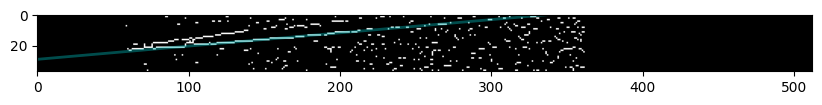

[{'angle_deg': 85.0,
  'slope': np.float64(0.08748866352592397),
  'velocity_km_s': np.float64(564.7109046629157),
  't_onset_idx': np.float64(29.110775288757075)}]

In [124]:
j_map = create_jmap(running_difference,100)
cme_hough_transform(j_map, 95,0)

### Fitting ellipse into blobs for CME detection

Main principle is fitting an ellipse inclined at an angle to the x-axis to the blob. The blobs are created by the meijering filter in j-maps. The ellipse is defined in parametric form:

$$
\frac{(x\cos{\theta} + y\sin{\theta})^2}{(L/2)^2} + \frac{(y\cos{\theta} - x\sin{\theta})^2}{(W/2)^2}= 1
$$

Where $A$ is the angle of the ellipse, $L$ is the length of the major axis and $W$ is the lenth of minor axis. The velocity is than calculated as:

$$
v = \left|\frac{1}{m}\right|\cdot \frac{dr}{dt}
$$

Where $dr$ is the change of arcsec per pixel and $dt$ is the change of time per pixel in seconds, and $m$ is th slope of the ellipse, but the slope is not the angle of the major axis of the ellipse, but its the leading edge of the ellipse. Slopes that are almost vertical or horizontal are not considered, as they would produce unrealistic velocities.

We check if the calculated velocity is realistic for a CME with this condition:
$$
250 \text{ km/s} < v < 2000 \text{ km/s}
$$

In [20]:
from sklearn.cluster import DBSCAN

def extract_velocity_with_ml(j_map_eq, cum_times_seconds, verbose=True):
    # (Assuming ARCSEC_TO_KM, arcsec_per_pixel, rsun_pixels are defined globally)
    
    # ---------------------------------------------------------
    # PART 1: MACHINE LEARNING (Find the faint CME track)
    # ---------------------------------------------------------
    # Use Frangi to highlight the continuous diagonal lines
    j_map_ridges = frangi(j_map_eq, sigmas=range(2, 5), black_ridges=False)
    
    # Lower threshold to keep the ultra-faint leading edge (tail)
    threshold = np.percentile(j_map_ridges, 90) 
    binary_map = j_map_ridges > threshold
    
    # Extract all surviving pixel coordinates (y=Time, x=Space)
    y_all, x_all = np.nonzero(binary_map)
    points = np.column_stack((x_all, y_all))
    
    if len(points) == 0:
        print("No signal found above threshold.")
        return None

    clustering = DBSCAN(eps=5, min_samples=8).fit(points)
    labels = clustering.labels_
    
    # Find the largest valid cluster (ignore -1, which is noise)
    unique_labels = set(labels)
    if -1 in unique_labels:
        unique_labels.remove(-1)
        
    if not unique_labels:
        print("Only noise found, no CME track.")
        return None
        
    biggest_cluster_label = max(unique_labels, key=lambda l: np.sum(labels == l))
    
    # Extract just the CME coordinates! 
    # THESE REPLACE YOUR OLD props.coords!
    cme_points = points[labels == biggest_cluster_label]
    cme_x = cme_points[:, 0].astype(int)
    cme_y = cme_points[:, 1].astype(int)

    if verbose:
        plt.figure(figsize=(10, 5))
        plt.imshow(j_map_eq, cmap='gray', origin='upper')
        plt.scatter(cme_x, cme_y, c='red', s=1, alpha=0.5, label="ML Detected CME")
        plt.legend()
        plt.show()

    # ---------------------------------------------------------
    # PART 2: VELOCITY MATH (Exact Cadence & Physical Units)
    # ---------------------------------------------------------
    unique_radii = np.unique(cme_x)
    
    # Find the leading (min) and trailing (max) edges of the ML cluster
    min_y_edge = np.array([np.min(cme_y[cme_x == r]) for r in unique_radii])
    max_y_edge = np.array([np.max(cme_y[cme_x == r]) for r in unique_radii])

    # Convert X-axis (pixels) to Physical Distance (km)
    R_arcsec_max = (1024 / 2) * arcsec_per_pixel
    R_arcsec_min = 3.7 * rsun_pixels * arcsec_per_pixel
    dr_arcsec_per_pixel = (R_arcsec_max - R_arcsec_min) / 512 
    physical_x_km = unique_radii * dr_arcsec_per_pixel * ARCSEC_TO_KM
    
    # Convert Y-axis (indices) to Exact Elapsed Seconds
    time_sec_min = cum_times_seconds[min_y_edge]
    time_sec_max = cum_times_seconds[max_y_edge]
    
    # Linear Regression (Space on X, Time on Y) to preserve thickness math
    slope_sec_per_km_min = np.polyfit(physical_x_km, time_sec_min, 1)[0]
    slope_sec_per_km_max = np.polyfit(physical_x_km, time_sec_max, 1)[0]
    
    # Invert slopes to get true Velocity (km/s)
    v_min_edge = abs(1.0 / slope_sec_per_km_min) if slope_sec_per_km_min != 0 else 0
    v_max_edge = abs(1.0 / slope_sec_per_km_max) if slope_sec_per_km_max != 0 else 0
    
    velocity_km_s = max(v_min_edge, v_max_edge)
    
    if verbose:
        print(f"ML Detected Velocity: {velocity_km_s:.1f} km/s")

    return velocity_km_s

In [21]:
def cme_blob_detection(j_map, cum_times_seconds, percentil, disk_size, verbose=True):
    j_map_clean = np.nan_to_num(j_map, nan=0.0, posinf=0.0, neginf=0.0)
    p1, p99 = np.percentile(j_map_clean, (1, 99))
    j_map_clipped = np.clip(j_map_clean, p1, p99)
    j_map_norm = (j_map_clipped - j_map_clipped.min()) / (j_map_clipped.max() - j_map_clipped.min())
    j_map_eq = exposure.equalize_adapthist(j_map_norm, clip_limit=0.05)

    j_map_ridges = frangi(j_map_eq, sigmas=range(2, 5), black_ridges=False)
    threshold = np.percentile(j_map_ridges, percentil) 
    binary_j_map = j_map_ridges > threshold
    binary_j_map = closing(binary_j_map, disk(disk_size))

    label_image = label(binary_j_map)

    if verbose:
        fig, ax = plt.subplots(figsize=(10, 5))
        ax.imshow(binary_j_map, cmap='gray', origin='upper')

    cme_detection = []

    for props in regionprops(label_image):
        
        if props.area < 40:
            continue

        y0, x0 = props.centroid
        
        major_axis = props.major_axis_length
        minor_axis = props.minor_axis_length
        
        orientation_rad = props.orientation
        angle_rad = orientation_rad + (np.pi / 2)
        center_xy = (x0, y0)

        """
        Start leading edge calculation of slope
        """
        x_coords = props.coords[:, 1]
        y_coords = props.coords[:, 0]
        
        unique_radii = np.unique(x_coords)

        min_y_edge = [np.min(y_coords[x_coords == r]) for r in unique_radii]
        max_y_edge = [np.max(y_coords[x_coords == r]) for r in unique_radii]

        slope_min = np.polyfit(unique_radii, min_y_edge, 1)[0]
        slope_max = np.polyfit(unique_radii, max_y_edge, 1)[0]
    
        slope = min(abs(slope_min), abs(slope_max))

        """
        End leading edge slope calculation
        """
        
        velocity_km_s = extract_velocity_with_ml(j_map_eq, cum_times_seconds, verbose=verbose)
        
        t_onset_idx = abs(y0 + slope * x0)
    
        if V_MIN_KM_S < velocity_km_s < V_MAX_KM_S:
            cme_detection.append({
                'x0': x0,
                'y0': y0,
                'angle_deg': math.degrees(angle_rad),
                'major_axis': major_axis,
                'minor_axis': minor_axis,
                'slope': slope,
                'velocity_km_s': velocity_km_s,
                't_onset_idx': math.floor(t_onset_idx)
            })

        if verbose and slope < 1:
            # ax.add_patch(ellipse_patch)         
            
            print(f"Blob at (x={x0:.0f}, y={y0:.0f}): Angle deg{math.degrees(angle_rad):.1f} deg, Length {major_axis:.1f}, angle rad {angle_rad:.1f}rad")
            print('slope: ', slope, 'velocity: ', velocity_km_s, 't_onset_index: ', t_onset_idx)
            print("-"*50)
            print()


    return cme_detection

C:\Users\Lukas\AppData\Local\Temp\ipykernel_21812\3206479693.py:18: RuntimeWarning: Mean of empty slice
  clean_radial_slice = np.nanmean(swath, axis=1)


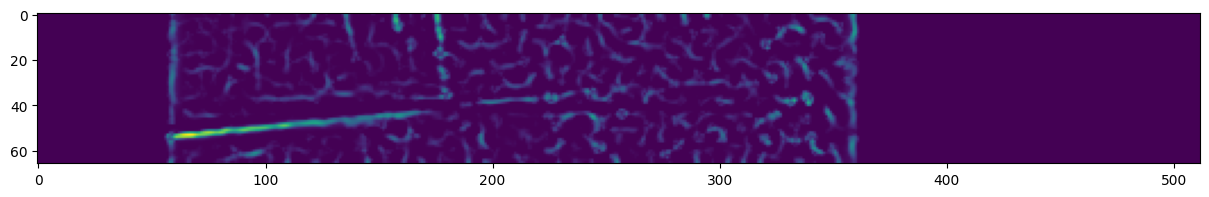

In [22]:


j_map = create_jmap(running_difference,100)
j_map_clean = np.nan_to_num(j_map, nan=0.0, posinf=0.0, neginf=0.0)
p1, p99 = np.percentile(j_map_clean, (1, 99))
j_map_clipped = np.clip(j_map_clean, p1, p99)
j_map_norm = (j_map_clipped - j_map_clipped.min()) / (j_map_clipped.max() - j_map_clipped.min())
j_map_eq = exposure.equalize_adapthist(j_map_norm, clip_limit=0.08)

j_map_ridges = frangi(j_map_eq, sigmas=range(2, 4), black_ridges=False)
threshold = np.percentile(j_map_ridges, 95) 
binary_j_map = j_map_ridges > threshold
binary_j_map = closing(binary_j_map, disk(2))
plt.figure(figsize=(15, 10))
plt.imshow(j_map_ridges)

In [23]:
def all_angles_detections_blobs(images):
    rows = []
    for angle in range(0, 360, 5):
        j_map = create_jmap(images, angle)
        cme = cme_blob_detection(j_map, cum_times_seconds=cum_times, percentil=95, disk_size=1, verbose=False)

        for r in cme:
            r['angle'] = angle
            rows.append(r)

    return pd.DataFrame(rows)

In [24]:
detections = all_angles_detections_blobs(running_difference)

detections = detections.sort_values(by='t_onset_idx').reset_index(drop=True)

detections['onset_diff'] = detections['t_onset_idx'].diff()
detections.fillna(0, inplace=True)
detections['cme_cluster_id'] = (detections['onset_diff'] > 1).cumsum()


C:\Users\Lukas\AppData\Local\Temp\ipykernel_21812\3206479693.py:18: RuntimeWarning: Mean of empty slice
  clean_radial_slice = np.nanmean(swath, axis=1)
C:\Users\Lukas\AppData\Local\Temp\ipykernel_21812\486669693.py:28: FutureWarning: `RegionProperties.major_axis_length` is deprecated starting in version 0.26 and will be removed in version 2.0. Use `RegionProperties.axis_major_length` instead. 
  major_axis = props.major_axis_length
C:\Users\Lukas\AppData\Local\Temp\ipykernel_21812\486669693.py:29: FutureWarning: `RegionProperties.minor_axis_length` is deprecated starting in version 0.26 and will be removed in version 2.0. Use `RegionProperties.axis_minor_length` instead. 
  minor_axis = props.minor_axis_length
C:\Users\Lukas\AppData\Local\Temp\ipykernel_21812\486669693.py:28: FutureWarning: `RegionProperties.major_axis_length` is deprecated starting in version 0.26 and will be removed in version 2.0. Use `RegionProperties.axis_major_length` instead. 
  major_axis = props.major_axis_le

In [25]:
counts = detections['cme_cluster_id'].value_counts()
valid_clusters = counts[counts > 10].index
detections = detections[detections['cme_cluster_id'].isin(valid_clusters)]

detections['cme_cluster_id'].unique()



array([10])

In [26]:
flat_clusters = pd.DataFrame()

for c in detections['cme_cluster_id'].unique():
    cc = detections[detections['cme_cluster_id'] == c].groupby('angle').agg({
            't_onset_idx': 'median', # Pandas automatically finds the median timestamp!
            'velocity_km_s': 'mean',
            'cme_cluster_id': 'min'
        }).reset_index()

    flat_clusters = pd.concat([flat_clusters, cc])



In [27]:
def fill_factor(cluster):
    c1_angles = cluster['angle'].sort_values().values # Ensure it's a numpy array
    
    if len(c1_angles) <= 1:
        return 0.0, 0.0
        
    gaps = np.diff(c1_angles)
    wrap_gap = (360 - c1_angles[-1]) + c1_angles[0]
    all_gaps = np.append(gaps, wrap_gap)
    
    c1_AW = 360 - np.max(all_gaps)
    
    if c1_AW == 0:
        return 0.0, 0.0
        
    FF_c1 = (len(c1_angles) / ((c1_AW / 5) + 1)) * 100
    
    return min(100.0, FF_c1), c1_AW

In [31]:
def quality_score(flat_clusters):
    cluster_dict = {}

    for cluster_id in flat_clusters['cme_cluster_id'].unique():

        cluster = flat_clusters[flat_clusters['cme_cluster_id'] == cluster_id]

        # 'Velocity calculation:'
        cluster = cluster.sort_values('angle')
        smoothed_velocities = cluster['velocity_km_s'].rolling(window=3, center=True, min_periods=1).median()
        true_cme_velocity = smoothed_velocities.max()
        

        v = cluster['velocity_km_s']
        t = cluster['t_onset_idx']

        cv_t = t.std() / t.mean() if t.mean() != 0 else 1.0
        cv_v = v.std() / v.mean() if v.mean() != 0 else 1.0

        FF, AW = fill_factor(cluster)

        norm_AW = AW / 360.0
        norm_FF = FF / 100.0
        
        norm_cv_v = max(0.0, 1.0 - cv_v)
        norm_cv_t = max(0.0, 1.0 - cv_t)

        qs = (0.4 * norm_AW) + (0.3 * norm_FF) + (0.15 * norm_cv_v) + (0.15 * norm_cv_t)


        ot = math.floor(t.mean().item())
        iot = len(images) - ot if ot < len(images) and ot >= 0 else 0
        onset_image_date, onset_image_datetime, _, _ = os.listdir(main_image_dir)[iot].split('_')

        cluster_dict[cluster_id.item()] = {
            "zscore_velocity": cv_v.item(),
            "zscore_onset_time": cv_t.item(),
            "velocity_km_s": true_cme_velocity,
            "onset_time_idx": ot,
            'onset_time_inverse_idx': iot,
            'onset_date': onset_image_date,
            'onset_datetime': onset_image_datetime,
            "angular_width": AW.item(),
            'fill_factor': FF.item(),
            'THETA': qs.item()
        }

    return cluster_dict

In [32]:
quality_score(flat_clusters)

{10: {'zscore_velocity': 0.50638265213166,
  'zscore_onset_time': 0.07533865401456011,
  'velocity_km_s': np.float64(1274.3555848479386),
  'onset_time_idx': 53,
  'onset_time_inverse_idx': 14,
  'onset_date': '20150621',
  'onset_datetime': '0330',
  'angular_width': 340,
  'fill_factor': 72.46376811594203,
  'THETA': 0.8079108862036708}}

**Test score for clusters**
Let $Q$ be a cluster, $Q = \{q_1, q_2, \ldots, q_n\}$, where $q_i$ is a detection. We than calculate the score $\Theta$ for the cluster $Q$ as:
$$
\Theta_{Q} = w_1\Delta\theta_Q + w_2CV_{Q_t} + w_3CV_{Q_v}  
$$

**Fill Factor** tells us how continuous is the cluster. When our true angular width $\Delta\theta_Q$ of the cluster $Q$ is for example 340 degrees, then we expect at least $340/5$ (divided by 5 because that is our resolution) detections in the cluster $Q$, we will call this value as expected number of detections $\epsilon_Q = \Delta\theta_Q/5$ and the true number of **unique** detections will be just $|Q|$ the size of the set. 
$$
FF_Q = \frac{|Q|}{\epsilon_Q} \cdot 100
$$
We can incorporate this into our score:
$$
\Theta_{Q} = w_1\Delta\theta_Q + w_4FF_Q + w_2CV_{Q_t} + w_3CV_{Q_v}
$$

Where CV is coeffcient of variation of the clusters velocity and onset time. We invert its value to make a higher value better. Like so:
$$
CV_{Q_t} = \text{max}(0, 1 - CV_{Q_t} )
$$
$$
CV_{Q_v} = \text{max}(0, 1 - CV_{Q_v} )
$$

Very important note is that the values $\Delta\theta_Q$, $CV_{Q_t}$, $CV_{Q_v}$ are normalized. So we have to weigh them respectively with values which sum is 1 so that the final value is also between 0 and 1. So:
$$
\sum_{i = 1}^{4} w_i = 1
$$
NOTE: Before you even calculate the cluster's overall variances or width, you should "flatten" the duplicates. Group the detections in the cluster by their PA, and take the median velocity and median onset time for each PA.

**2.5D plot**
This next scatter plot of angle and onset time, colored by speed shows when the cme was detected at different angles. It basically shows the gemoetry and topology of the CME. We can see faster detections at smaller angles and slower detections at larger angles. That tells us that the CME was faster in the first quadrant than in it was in the third and fourth quadrant. The first 100 angles are the faster front of the detection and it was detected earlier than the slower front.

This is also the argument for taking the 90th percentile of the speed as the final speed of the CME. 


On the plot to the right we can see detections colored by cluster number. The main CME cluster is nicely spread out as single line throughout all angles, while the other clusters are just seemingly random detections. By setting sharey=True we can see that the left plot is really a nice line from the plot on the right.

Text(0.5, 0, 'Position Angle (Degrees)')

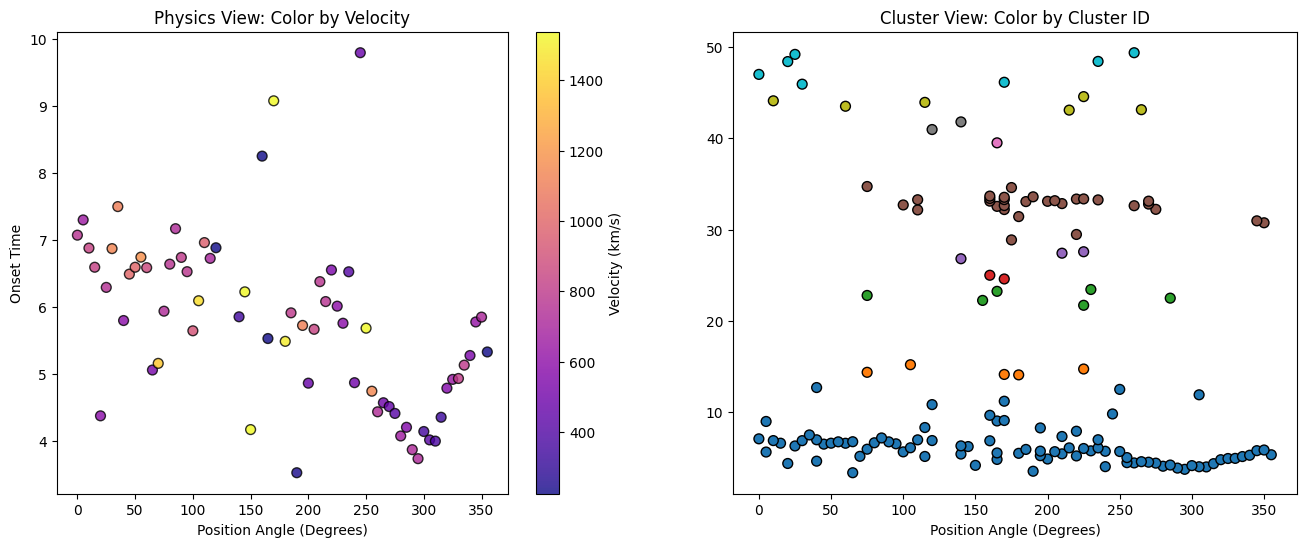

In [184]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharey=False)

# PLOT A: The "Physics View" (Color = Velocity)
# This helps you see if the physics make sense (smooth velocity change)
sc1 = ax1.scatter(flat_c1['angle'], flat_c1['t_onset_idx'], c=c1_v, cmap='plasma', s=50, edgecolors='k', alpha=0.8)
ax1.set_title('Physics View: Color by Velocity')
ax1.set_xlabel('Position Angle (Degrees)')
ax1.set_ylabel('Onset Time')
fig.colorbar(sc1, ax=ax1, label='Velocity (km/s)')


c2 = ax2.scatter(detections['angle'], detections['t_onset_idx'], c=detections['cme_cluster_id'], cmap='tab10', s=50, edgecolors='k')
ax2.set_title('Cluster View: Color by Cluster ID')
ax2.set_xlabel('Position Angle (Degrees)')

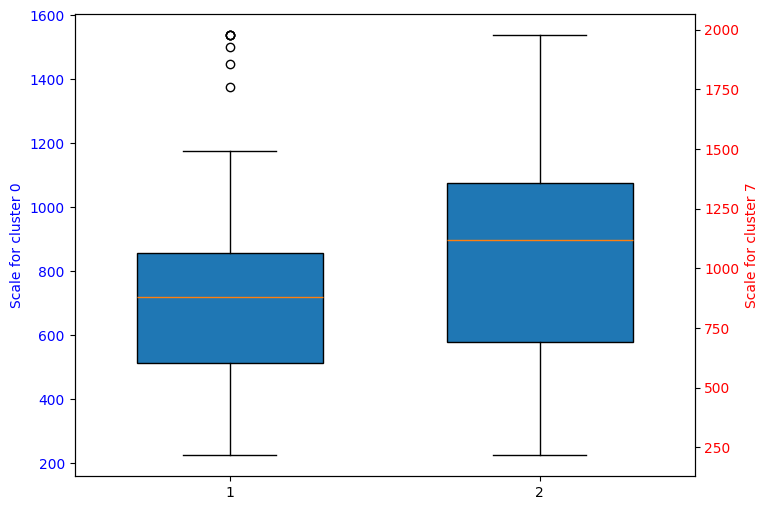

In [173]:
fig, ax1 = plt.subplots(figsize=(8, 6))

# Plot the first box on the left axis
box1 = ax1.boxplot([c1_v], positions=[1], widths=0.6, patch_artist=True)
ax1.set_ylabel('Scale for cluster 0', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Create a twin axis for the second dataset
ax2 = ax1.twinx()
box2 = ax2.boxplot([flattened_c2['velocity_km_s']], positions=[2], widths=0.6, patch_artist=True)
ax2.set_ylabel('Scale for cluster 7', color='red')
ax2.tick_params(axis='y', labelcolor='red')

### Creating time series attribute for GRU model

The main idea is to create time series of angular width and of velocity. The velocity will be modeled with drag based model. We will use the intial velocity calculated with the cme detection algorithm as initial condition for the equation for velocity over time:

$$
v(t) = \frac{v_0 - w}{1 +\gamma(v_0 - w)t} + w
$$

where $v_0$ is the initial velocity, $w$ is the wind velocity, $\gamma$ is the drag coefficient which we will set to $0.5 \times 10^{-7}$, this will we be later adjusted based on the angular width of CMEs, if the CME is halo, that means it has more mass, so it will go through space easier and should experience lower drag compared to CMEs with angular width less than 120 degrees. $t$ is the time elapsed since launch in seconds.

The velocity function give us velocity at time t, so we will need a time span in which the cme is propagating through space towards earth. That we will calculate by solving this equation for $t$:
$$
r(t) = \frac{1}{\gamma} \ln{1 + \gamma(v_0 - w)t} + tw + r_0.
$$

This equation is transcendental and we will use numerical methods to solve it.


**Angular width attribute**

The attribute telling the model the angular width will give the model sense of mass of the function. We will create simple step function, when the cme start the line jumps from 0 to $\Delta \omega$ and then it goes back to 0 after the cme arrives. CME cant change its width during the transit, thus we have nothing to model.


In [387]:
def get_gamma_by_width(angular_width_deg):
    if angular_width_deg >= 120:
        return 0.2e-7 
    elif angular_width_deg >= 60:
        return 0.5e-7 
    else:
        return 1.5e-7

def calculate_transit_time(v0, width_deg, target_dist_km, w=450):
    
    gamma = get_gamma_by_width(width_deg)
    
    t_guess = target_dist_km / v0 
    for _ in range(10): 
        r_guess = (1/gamma) * np.log(1 + gamma * (v0 - w) * t_guess) + w * t_guess
        v_at_guess = (v0 - w) / (1 + gamma * (v0 - w) * t_guess) + w
        diff = target_dist_km - r_guess
        t_guess += diff / v_at_guess
    
    transit_time = t_guess
    
    return transit_time


In [388]:
TT = calculate_transit_time(1174.40, 355, 149597870.7)
TT

np.float64(186854.81509151834)

The cme_start_date will be determined by the date on the donwloaded images. For this crrent event we got t onset index approximately as 6 from the ellipse algorithm. We have 54 images so $54 - 6 = 48$ so the name of 48th image has the date of the cme start. 

In [ ]:
cme_start_date = '2023-04-21 19:18:00'
v0 = 1174.40           # Initial speed
width = 355
w = 400             # Solar wind speed
gamma = get_gamma_by_width(width)

loc_idx = DATA.index.get_indexer([pd.to_datetime(cme_start_date)], method='nearest')[0]
cme_launch_time = DATA.index[loc_idx]

cme_arrival_time = cme_launch_time + pd.Timedelta(seconds=TT)

mask_transit = (DATA.index >= cme_launch_time) & (DATA.index <= cme_arrival_time)
t_seconds = (DATA.index[mask_transit] - cme_launch_time).total_seconds()
cme_velocity_values = w + (v0 - w) / (1 + gamma * (v0 - w) * t_seconds)

DATA["CME_Simulated_Velocity"] = 0.0 
DATA.loc[mask_transit, "CME_Simulated_Velocity"] = cme_velocity_values

In [419]:
DATA['Angular_Width'] = 0
DATA.loc[mask_transit, 'Angular_Width'] = width

In [425]:
DATA['Simulated_Impact_Pressure'] = (
    DATA['Angular_Width'] * (DATA['CME_Simulated_Velocity'] ** 2)
) / 1E6

<Axes: xlabel='Time'>

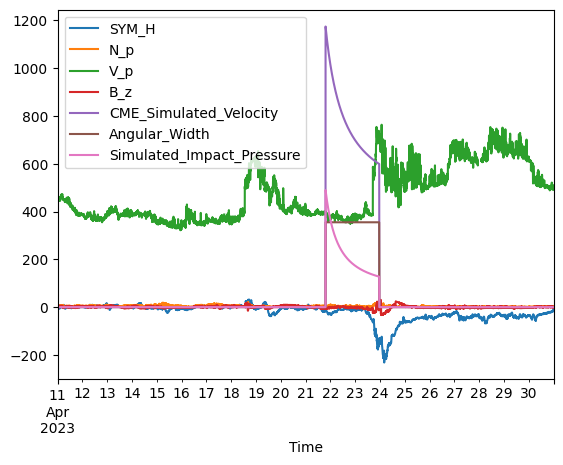

In [426]:
DATA.plot()

## 2 InSitu data

In [1]:
import os, shutil
from extractDataSrc.Lasco import Lasco
from extractDataSrc.InSitu import InSitu
from extractDataSrc.Eit195 import Eit195
from datetime import datetime, timedelta

import sunpy.timeseries as ts
from sunpy.net import Fido, attrs as a
from extractDataSrc.Hapi import get_hapi_data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import sunpy
from sunpy.net import attrs as a
from astropy.time import Time
import astropy.units as u
import sunpy.map
import scipy.ndimage as ndi
import albumentations
import cv2 as cv
import scipy

from PIL import Image
import json
import requests


c:\Users\Lukas\miniconda3\envs\space_lab\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [374]:
start = '2023-04-11 00:00:00'
end = '2023-05-01'

print('Downloading B data -----------------')
insitu = InSitu(start, end)
insitu.extract_data("B", verbose=True)

B = pd.read_csv('./data_processed/in_situ/B_data.csv')
B.index = pd.to_datetime(B['Time'])
B.drop('Time', axis=1, inplace=True)
B['B'] = np.sqrt(B['B_x']**2 + B['B_y']**2 + B['B_z']**2) 

B = B.resample('3min').mean()
print('Done')

print('Downloading SOHO CELIAS N_p (30s cadence) -----------------')
insitu = InSitu(start, end)
insitu.extract_data("N_p", verbose=True)

N = pd.read_csv('./data_processed/in_situ/B_data.csv')
N.index = pd.to_datetime(N['Time'])
N.drop('Time', axis=1, inplace=True)

N = N.resample('3min').mean()

print('Downloading SOHO CELIAS V_p (30s cadence) -----------------')
insitu = InSitu(start, end)
insitu.extract_data("V_p", verbose=True)

V = pd.read_csv('./data_processed/in_situ/B_data.csv')
V.index = pd.to_datetime(V['Time'])
V.drop('Time', axis=1, inplace=True)

V = V.resample('3min').mean()

print('Downloading SYM_H -----------------')
server = 'https://cdaweb.gsfc.nasa.gov/hapi'
dataset = 'OMNI_HRO_1MIN'
parameter = 'SYM_H'

hapi_data = get_hapi_data(server, dataset, parameter, start, end)

SYM_data = []
for record in hapi_data:
    row = []
    row.append(record[0])
    row.append(round(record[1], 3))
    SYM_data.append(row)

SYM_H = pd.DataFrame(data=SYM_data, columns=["Time", 'SYM_H'])
SYM_H['Time'] = SYM_H['Time'].str.decode('utf-8')
SYM_H.index = pd.to_datetime(SYM_H['Time'], format="%Y-%m-%dT%H:%M:%S.000Z")
SYM_H.drop('Time', axis=1, inplace=True)
SYM_H = SYM_H.resample('3min').mean()

print("Done")


transforming data...
saving data...
Done
Done
transforming data...
saving data...
Done
transforming data...
saving data...
Done
Done


<Axes: xlabel='Time'>

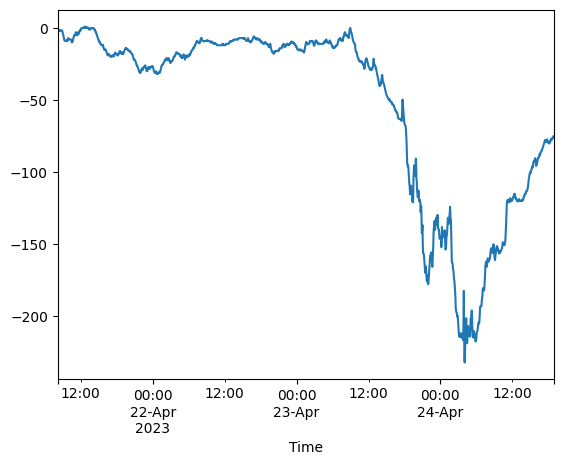

In [406]:
DATA = pd.concat([SYM_H, N, V, B['B_z']], axis=1)
DATA['SYM_H'].loc['2023-04-21 08:06:07':'2023-04-24 18:54:07'].plot()

In [376]:
DATA

,SYM_H,N_p,V_p,B_z
Time,,,,
2023-04-11 00:00:00,-5.000000,4.295000,448.666667,4.810000
2023-04-11 00:03:00,-5.666667,3.985000,448.333333,4.323000
2023-04-11 00:06:00,-5.333333,3.933333,451.166667,4.241333
2023-04-11 00:09:00,-5.666667,4.250000,448.166667,5.050000
2023-04-11 00:12:00,-5.666667,4.328333,450.833333,5.109333
...,...,...,...,...
2023-04-30 23:45:00,-14.333333,3.040000,502.833333,-2.225333
2023-04-30 23:48:00,-15.333333,3.015000,497.666667,-1.644333
2023-04-30 23:51:00,-16.333333,3.001667,496.666667,-2.398667
